# KNN Classifier Tuning (Breast Cancer Dataset)

This project explores how KNN performance changes with:
- Different values of K (1 to 15)
- Different distance metrics (Euclidean vs Manhattan)

We also visualize accuracy trends.

## Objective

- Load breast cancer dataset
- Train KNN classifier
- Test different values of K (1–15)
- Compare Euclidean vs Manhattan distance
- Plot Accuracy vs K
- Understand why accuracy changes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

## Load Dataset

We use the built-in Breast Cancer dataset from sklearn.

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

## Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## 1. Euclidean Distance (p = 2)

We test K values from 1 to 15.

In [4]:
k_values = range(1, 16)
accuracies_euclidean = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies_euclidean.append(acc)

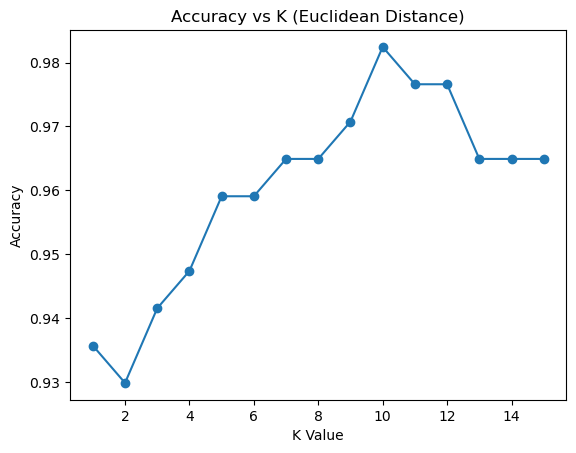

In [5]:
plt.plot(k_values, accuracies_euclidean, marker='o')
plt.title("Accuracy vs K (Euclidean Distance)")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()

## 2. Manhattan Distance (p = 1)

In [6]:
accuracies_manhattan = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies_manhattan.append(acc)

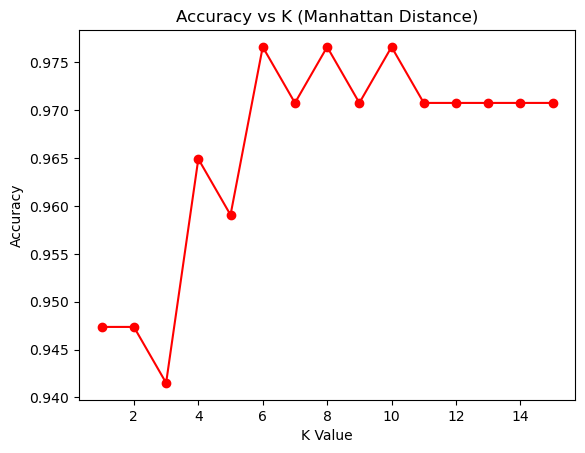

In [7]:
plt.plot(k_values, accuracies_manhattan, marker='o', color='red')
plt.title("Accuracy vs K (Manhattan Distance)")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()

## Comparison: Euclidean vs Manhattan

In [8]:
for k in k_values:
    print(
        f"K={k} | Euclidean Acc={accuracies_euclidean[k-1]:.4f} | "
        f"Manhattan Acc={accuracies_manhattan[k-1]:.4f}"
    )

K=1 | Euclidean Acc=0.9357 | Manhattan Acc=0.9474
K=2 | Euclidean Acc=0.9298 | Manhattan Acc=0.9474
K=3 | Euclidean Acc=0.9415 | Manhattan Acc=0.9415
K=4 | Euclidean Acc=0.9474 | Manhattan Acc=0.9649
K=5 | Euclidean Acc=0.9591 | Manhattan Acc=0.9591
K=6 | Euclidean Acc=0.9591 | Manhattan Acc=0.9766
K=7 | Euclidean Acc=0.9649 | Manhattan Acc=0.9708
K=8 | Euclidean Acc=0.9649 | Manhattan Acc=0.9766
K=9 | Euclidean Acc=0.9708 | Manhattan Acc=0.9708
K=10 | Euclidean Acc=0.9825 | Manhattan Acc=0.9766
K=11 | Euclidean Acc=0.9766 | Manhattan Acc=0.9708
K=12 | Euclidean Acc=0.9766 | Manhattan Acc=0.9708
K=13 | Euclidean Acc=0.9649 | Manhattan Acc=0.9708
K=14 | Euclidean Acc=0.9649 | Manhattan Acc=0.9708
K=15 | Euclidean Acc=0.9649 | Manhattan Acc=0.9708


## Why Accuracy Changes with K?

- Small K (e.g., 1):
  - Very sensitive to noise
  - Can overfit

- Large K:
  - Too smooth decision boundary
  - May underfit

- Optimal K:
  - Balanced bias and variance
  - Gives best accuracy

### Distance Metric Effect:
- Euclidean (L2): Straight-line distance
- Manhattan (L1): Grid-like distance

Different metrics change neighbor selection → affects prediction.

## Conclusion

- Best K lies between 3–10 usually
- Euclidean and Manhattan give slightly different results
- KNN is highly sensitive to K value and distance metric